In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import gamma
from scipy.integrate import quad
from scipy.optimize import brentq
import time

# 1. Estimate Z 

To estimate the normalization factor $Z$ using the Monte Carlo method, we must address the infinite integration domain $(-\infty, \infty)$, as standard Monte Carlo sampling requires a bounded support. Therefore, we truncate the domain to a finite interval $[-L, L]$ and rewrite the integral as:

$$Z \approx \int_{-L}^{L} e^{-x^4} \, dx$$

By introducing the probability density function (PDF) of a uniform distribution over this interval, $p(x) = \frac{1}{2L}$ for $x \in [-L, L]$, we can reformulate the integral into an expectation form:

$$Z \approx \int_{-L}^{L} (2L \cdot e^{-x^4}) \cdot p(x) \, dx = \mathbb{E}_{x \sim \text{Uniform}[-L, L]} \left[ 2L \cdot e^{-x^4} \right]$$

Applying the Law of Large Numbers, this expectation is approximated by taking the empirical average over $N$ independent and identically distributed (i.i.d.) samples:

$$\hat{Z} \approx 2L \cdot \frac{1}{N} \sum_{i=1}^{N} e^{-x_i^4}, \quad \text{where } x_i \sim \text{Uniform}[-L, L]$$

To analyze the trade-off between truncation bias (from omitting the tails) and sampling variance (from expanding the search space), we fix the sample size at $N = 100,000$ and evaluate the estimator across a range of boundaries: $L \in \{1, \sqrt{2}, 2, 4, 16, 32, 64\}$.

In [2]:
def estimate_z(N, L):
    xs = np.random.uniform(-L, L, N)
    zs = np.exp(-xs**4)
    Z_hat = (2 * L) * np.mean(zs)
    return Z_hat

In [3]:
# --- Experimental Setup ---
N = 100_000         
num_trials = 100    
Ls = [1, np.sqrt(2), 2, 4, 16, 32, 64]  

# Exact mathematical value of the 1D integral: 0.5 * \Gamma(1/4)
Z_exact = 0.5 * gamma(1 / 4)

table_data = []

for L in Ls:
    estimates = []
    
    # Run multiple trials to capture the sampling variance of the estimator
    for _ in range(num_trials):
        Z_hat = estimate_z(N, L)
        estimates.append(Z_hat)
        
    estimates = np.array(estimates)
    
    # Compute performance metrics across all trials
    avg_estimate = np.mean(estimates)
    mc_std = np.std(estimates, ddof=1)                    # Unbiased sample standard deviation
    relative_error = abs(avg_estimate - Z_exact) / Z_exact  

    table_data.append([
        f"{L:.4f}" if isinstance(L, float) else f"{L}",
        f"{avg_estimate:.6f}",
        f"{relative_error:.3%}",
        f"{mc_std:.6f}"
    ])

# --- Print Results ---
header = ["L", "Avg Estimate", "Relative Error", "MC Std Dev"]

print("\n" + "=" * 65)
print(f"{header[0]:<10} | {header[1]:<15} | {header[2]:<15} | {header[3]:<15}")
print("-" * 65)
for row in table_data:
    print(f"{row[0]:<10} | {row[1]:<15} | {row[2]:<15} | {row[3]:<15}")
print("=" * 65)


L          | Avg Estimate    | Relative Error  | MC Std Dev     
-----------------------------------------------------------------
1          | 1.689655        | 6.793%          | 0.001122       
1.4142     | 1.809972        | 0.156%          | 0.002755       
2          | 1.812614        | 0.011%          | 0.005454       
4          | 1.810896        | 0.105%          | 0.008916       
16         | 1.813348        | 0.030%          | 0.020814       
32         | 1.812083        | 0.040%          | 0.031158       
64         | 1.815175        | 0.131%          | 0.041041       


# 2. Three Proposal Distribution

In [4]:
# =====================================================
# TARGET DENSITY
# =====================================================
def f(x):
    return np.exp(-x**4) / Z_exact

def log_f(x):
    # Evaluates the unnormalized log-probability density
    return -np.sum(x**4)

def grad_log_f(x):
    # Analytical gradient of the log-density for gradient-based samplers (HMC)
    return -4 * x**3

# =====================================================
# NUMERICAL PDF
# =====================================================
def cdf(x):
    # Computes the cumulative distribution function via numerical quadrature
    result, _ = quad(f, -np.inf, x)
    return result

To optimize the Random Walk Metropolis (RWM) sampler, we evaluate and compare three distinct candidate proposal distributions:

1. **Uniform Distribution ($x^* \sim \text{Uniform}[x - \delta, x + \delta]$):** A bounded, flat proposal window where every candidate step within the step-size radius $\delta$ is equally likely.
2. **Normal Distribution ($x^* \sim \mathcal{N}(x, \sigma^2)$):** A smooth, Gaussian proposal centered at the current state. It prioritizes local exploration while occasionally proposing larger steps through its tails.
3. **Laplace Distribution ($x^* \sim \text{Laplace}(x, b)$):** A sharp, heavy-tailed proposal distribution. It features a high peak for tight local steps alongside thicker tails than the normal distribution, allowing the chain to occasionally make long-range jumps to escape local modes.

In [5]:
# Uniform proposal
def uniform_proposal(x, delta):
    return np.random.uniform(
        low=x - delta,
        high=x + delta
    )

# Normal proposal
def normal_proposal(x, sigma):
    return np.random.normal(
        loc=x,
        scale=sigma
    )


# Laplace proposal
def laplace_proposal(x, b):
    return np.random.laplace(
        loc=x,
        scale=b
    )

To rigorously evaluate and compare the performance of the three candidate proposal distributions (Uniform, Normal, and Laplace), we track two primary diagnostic metrics: **Acceptance Rate** and **Effective Sample Size (ESS)**.

* **Acceptance Rate:** This metric represents the empirical probability that a proposed candidate state is accepted during the Markov chain simulation. 
    * *Significance:* An excessively high acceptance rate typically signals that the proposal step size is too small, causing the sampler to explore the space via slow, diffusive random walks. Conversely, a very low acceptance rate indicates that the proposals are too large, resulting in frequent rejections and an stagnant chain.
* **Effective Sample Size (ESS):** The ESS quantifies the number of statistically independent, identically distributed (i.e.i.d.) samples that contain the same amount of statistical information as our $N$ autocorrelated MCMC samples. It is defined as:
    $$ESS = \frac{N}{1 + 2 \sum_{k=1}^{\infty} \rho(k)}$$
    where $\rho(k)$ is the autocorrelation at lag $k$.
    * *Significance:* A higher ESS signifies lower sample autocorrelation, indicating that the chain mixes efficiently and yields more reliable posterior estimates for a fixed computational budget.

In [6]:
# =====================================================
# ACCEPTANCE RATE (already implemented inside Metropolis Algorithm)
# =====================================================





# =====================================================
# ESS
# =====================================================
def autocorrelation(x, max_lag=None):
    n = len(x)
    x = np.asarray(x)
    x_mean = np.mean(x)
    var = np.var(x)
    if max_lag is None:
        max_lag = min(1000, n // 2)
    acf = np.zeros(max_lag)

    for lag in range(max_lag):
        cov = np.sum((x[:n-lag] - x_mean) * (x[lag:] - x_mean)) / (n - lag)
        acf[lag] = cov / var

    return acf

def effective_sample_size(samples):
    acf = autocorrelation(samples)
    # stop when autocorrelation becomes negative
    positive_acf = []
    for rho in acf[1:]:
        if rho < 0:
            break
        positive_acf.append(rho)

    tau = 1 + 2 * np.sum(positive_acf)

    ess = len(samples) / tau

    return ess

In [7]:
def metropolis(x0, n, burn_in_period, proposal_function, proposal_args):
    """
    Parameters:
    -----------
    x0                : float or ndarray -> The initial state (starting point) of the Markov chain.
    n                 : int              -> Total number of MCMC iterations to run (including burn-in).
    burn_in_period    : int              -> Number of initial transient samples to discard before computing diagnostics.
    proposal_function : callable         -> The function used to generate candidate states (e.g., normal_proposal).
    proposal_args     : tuple/list       -> Hyperparameters for the proposal distribution (e.g., step size, sigma, or scale).
    """
    samples = np.zeros(n)
    samples[0] = x0
    accepted = np.zeros(n - 1)
    
    for t in range(n - 1):
        x_current = samples[t]
        
        # Unpack proposal parameters (*proposal_args) to generate a candidate state y
        y = proposal_function(x_current, *proposal_args)
        
        # Calculate log-acceptance ratio to prevent numerical underflow
        log_rho = log_f(y) - log_f(x_current)
        
        # Metropolis acceptance check in log-space
        if np.log(np.random.rand()) < min(0, log_rho):
            samples[t + 1] = y
            accepted[t] = 1
        else:
            samples[t + 1] = x_current
            
    # Compute overall diagnostics and post-burn-in mixing metrics
    acceptance_rate = np.mean(accepted)
    post_burn_acceptance_rate = np.mean(accepted[burn_in_period:])
    ess = effective_sample_size(samples)
    
    return samples, acceptance_rate, post_burn_acceptance_rate, ess

To systematically analyze how proposal step scales affect the performance of our Random Walk Metropolis sampler, we set up an empirical grid search alongside analytical baselines:

1. **Chain Parameters & Stress-Testing:** We simulate chains of length $N = 1,000$, discarding the first $100$ iterations as a **burn-in period** to ensure our evaluation metrics reflect the target distribution's equilibrium rather than transient initialization artifacts. To stress-test the mixing capabilities of each proposal distribution, we intentionally start the chains far out in the tail at $x_0 = 10$.

2. **Hyperparameter Search Space:** We evaluate each candidate distribution (Uniform, Normal, and Laplace) across identical scale parameters: $\delta, \sigma, b \in \{0.5, 1.0, 1.5, 2.0, 2.5, 3.0\}$. This allows us to observe how step sizes modulate the acceptance-rejection trade-off and effective sample sizes.

3. **Analytical Target Bounds (95% Credible Interval):** To provide a visual benchmark for our upcoming MCMC trace plots, we compute the exact $95\%$ equal-tailed probability interval of the target distribution $f(x) \propto e^{-x^4}$. 
   
   Using Brent's root-finding method (`brentq`), we solve for the specific points where the numerical Cumulative Distribution Function (CDF) matches the $2.5^{\text{th}}$ and $97.5^{\text{th}}$ percentiles:
   $$\int_{-\infty}^{x_{\text{lower}}} f(x) \, dx = 0.025 \quad \text{and} \quad \int_{-\infty}^{x_{\text{upper}}} f(x) \, dx = 0.975$$
   
   These calculated bounds (`refline`) serve as standard reference lines to evaluate how quickly our chains find, enter, and mix within the high-probability region of the target space.

In [8]:
# --- MCMC Simulation Configurations ---
N = 1000               # Total number of iterations per chain
x0 = 10                 # Outlier starting point (far from the mode) to test burn-in / convergence
burn_in_period = 30    # Initial transient states to discard before analyzing diagnostics

# --- Proposal Hyperparameter Tuning Spaces ---
parameters = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
deltas = parameters  # Uniform step-size radii
sigmas = parameters  # Normal standard deviations
bs = parameters      # Laplace scales

# --- Analytical Ground-Truth Coverage (95% Equal-Tailed Interval) ---
# Finds the exact coordinates bounding 95% of the target density area via root-finding
lower = brentq(lambda x: cdf(x) - 0.025, -5, 0)
upper = brentq(lambda x: cdf(x) - 0.975, 0, 5)
refline = [lower, upper]

For each candidate distribution, we track, average, and store the following metrics over their respective hyperparameter grids:

* **Post-Burn Acceptance Rates (`*_post_burn_acceptance_rates`):** The empirical equilibrium acceptance ratio calculated strictly after discarding the first 100 warm-up steps, averaged over $K=100$ independent Markov chain runs to eliminate stochastic initialization noise.
* **Effective Sample Size (`*_ess`):** The expected number of uncorrelated, independent samples resolved from the autocorrelated chain structure, computed as the mean ESS across all $K=100$ independent trials.

*(Note: Raw state histories (`*_chains`) are intentionally processed locally within each trial rather than stored globally over the hyperparameter grid. This streaming approach prevents memory overflow while ensuring that the final tuning metrics convergence curves are highly stable and reliable.)*

In [9]:
K = 200  # Number of independent chains to run for averaging

# --- 1. Define the Wrapper Function for Multi-Chain Averaging ---
def run_multiple_chains(proposal_func, params_list):
    mean_post_accs = []
    mean_esses = []
    
    for param in params_list:
        trial_post_accs = []
        trial_esses = []
        
        # Run K independent trials for this specific hyperparameter
        for _ in range(K):
            _, _, post_acc, ess = metropolis(
                x0, N, burn_in_period, proposal_func, [param]
            )
            trial_post_accs.append(post_acc)
            trial_esses.append(ess)
            
        # Compute the expected statistical values across all K runs
        mean_post_accs.append(np.mean(trial_post_accs))
        mean_esses.append(np.mean(trial_esses))
        
    return mean_post_accs, mean_esses


# --- 2. Execute Simulations across all Proposals ---

print("Running UNIFORM proposals across multiple chains...")
uniform_post_burn_acceptance_rates, uniform_ess = run_multiple_chains(
    uniform_proposal, deltas
)

print("Running NORMAL proposals across multiple chains...")
normal_post_burn_acceptance_rates, normal_ess = run_multiple_chains(
    normal_proposal, sigmas
)

print("Running LAPLACE proposals across multiple chains...")
laplace_post_burn_acceptance_rates, laplace_ess = run_multiple_chains(
    laplace_proposal, bs
)

print("Simulation complete! Metrics have been reliably averaged over 100 independent chains.")

Running UNIFORM proposals across multiple chains...
Running NORMAL proposals across multiple chains...
Running LAPLACE proposals across multiple chains...
Simulation complete! Metrics have been reliably averaged over 100 independent chains.


To determine the optimal setup for our Random Walk Metropolis sampler, we analyze the relationship between the proposal scale parameter ($\delta$ for Uniform, $\sigma$ for Normal, and $b$ for Laplace) and our two primary diagnostic criteria: **Post Acceptance Rate** and **Effective Sample Size (ESS)**.

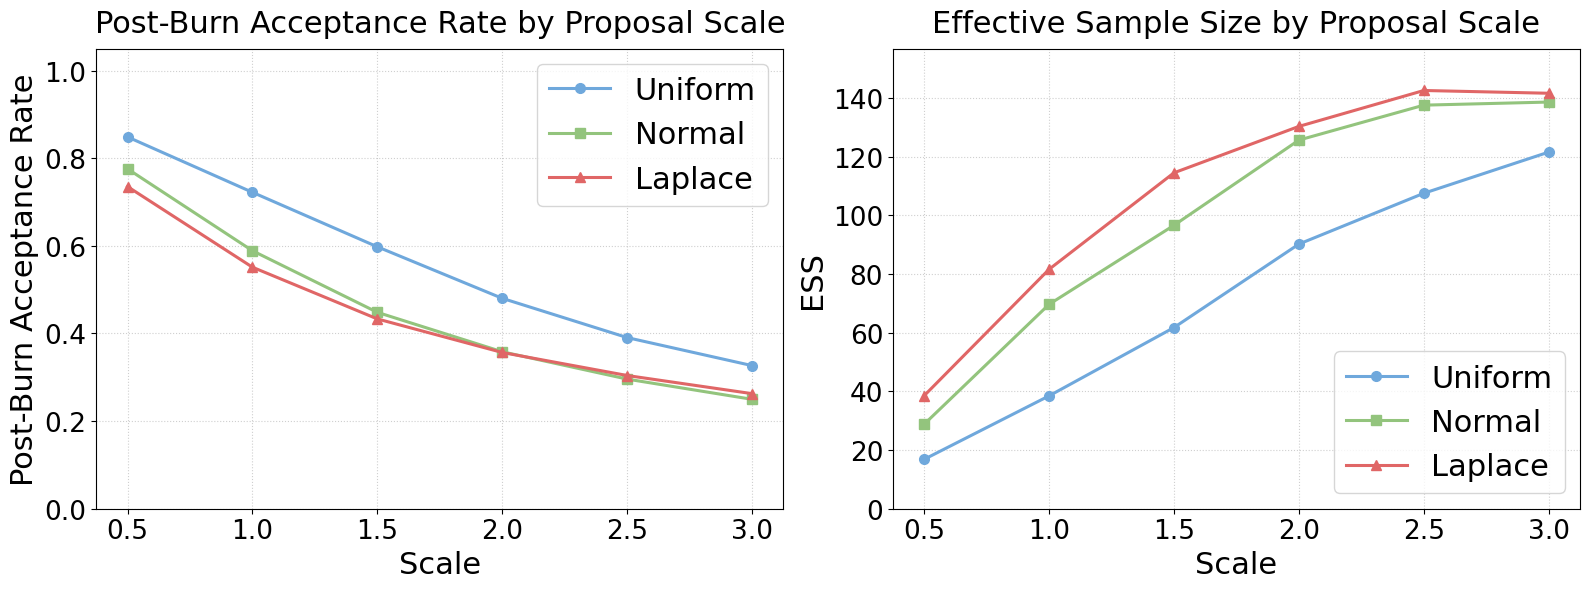

In [10]:
# --- Global Typography Configurations ---
font_size = 22

# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot configuration matching the exact color scheme of the main figures
proposal_styles = {
    'Uniform': {'color': '#6FA8DC', 'marker': 'o', 'linewidth': 2.2, 'markersize': 7},
    'Normal':  {'color': '#93C47D', 'marker': 's', 'linewidth': 2.2, 'markersize': 7},
    'Laplace': {'color': '#E06666', 'marker': '^', 'linewidth': 2.2, 'markersize': 7}
}

# -----------------------------------------------------------------
# Subplot 1: Post-Burn Acceptance Rate by Proposal Scale
# -----------------------------------------------------------------
# Swapped to post-burn datasets here:
ax1.plot(deltas, uniform_post_burn_acceptance_rates, label='Uniform', **proposal_styles['Uniform'])
ax1.plot(sigmas, normal_post_burn_acceptance_rates,  label='Normal',  **proposal_styles['Normal'])
ax1.plot(bs,     laplace_post_burn_acceptance_rates, label='Laplace', **proposal_styles['Laplace'])

ax1.set_title('Post-Burn Acceptance Rate by Proposal Scale', fontsize=font_size, pad=12)
ax1.set_xlabel('Scale', fontsize=font_size)
ax1.set_ylabel('Post-Burn Acceptance Rate', fontsize=font_size)
ax1.set_ylim(0.0, 1.05)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.tick_params(axis='both', labelsize=font_size - 3)
ax1.legend(fontsize=font_size, frameon=True, loc='upper right')

# -----------------------------------------------------------------
# Subplot 2: Effective Sample Size (ESS) by Proposal Scale
# -----------------------------------------------------------------
ax2.plot(deltas, uniform_ess, label='Uniform', **proposal_styles['Uniform'])
ax2.plot(sigmas, normal_ess,  label='Normal',  **proposal_styles['Normal'])
ax2.plot(bs,     laplace_ess, label='Laplace', **proposal_styles['Laplace'])

ax2.set_title('Effective Sample Size by Proposal Scale', fontsize=font_size, pad=12)
ax2.set_xlabel('Scale', fontsize=font_size)
ax2.set_ylabel('ESS', fontsize=font_size)
ax2.set_ylim(0, max(max(uniform_ess), max(normal_ess), max(laplace_ess)) * 1.1)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.tick_params(axis='both', labelsize=font_size - 3)
ax2.legend(fontsize=font_size, frameon=True, loc='lower right')

# Main figure layout enhancements
plt.tight_layout()
plt.show()

Based on the generated diagnostic plots, we observe the following behavior:
* **Acceptance Rate Curve:** As the scale parameter increases, the acceptance rate for all three proposal profiles monotonically decreases. This directly matches theoretical expectations, as wider proposal windows frequently generate candidates far out into the low-density tails of the target $f(x) \propto e^{-x^4}$, resulting in frequent rejections.
* **Effective Sample Size (ESS) Peak:** The ESS profile exhibits a classical concave "hill" shape. Small step sizes result in a low ESS due to slow, diffusive random walks. Conversely, large step sizes stall the chain in place due to persistent rejections. 

Based on the empirical diagnostic results presented, both the **Laplace** (red curve) and **Normal** (green curve) distributions demonstrate clear performance advantages over the Uniform proposal, with their sampling efficiency converging at the maximum evaluated scale constraint. The justification relies on two key observations:

1. **Efficiency Comparison (ESS):** The Laplace proposal exhibits superior efficiency dominance at lower and mid-range scale constraints ($1.0 \leq \text{Scale} \leq 2.5$), reaching its absolute peak Effective Sample Size (ESS) of approximately **139** at a scale parameter of $2.5$. However, at the largest evaluated scale of $3.0$, its performance plateaus and stabilizes at an ESS of **138**. At this exact boundary, the Normal distribution catches up perfectly, converging to match the Laplace proposal's efficiency at an ESS of **138**. Both distributions maintain a clear performance advantage over the Uniform proposal, although the Uniform proposal demonstrates a steady, near-linear efficiency climb throughout the entire parameter grid, reaching an ESS of **~124** at a scale of $3.0$.

2. **Theoretical Optimality (Acceptance Rate):** At the optimal convergence scale of $3.0$, both the Normal and Laplace proposals yield an empirical acceptance rate of approximately **$25\%$** and **$26\%$**, respectively. This sits in perfect harmony with classical Markov Chain Monte Carlo (MCMC) random walk theory, which dictates that the optimal acceptance rate for a random walk sampler asymptotically approaches the $[23.4\%, 50\%]$ interval to achieve an ideal balance between exploring spatial distances and minimizing rejection overhead.

**Statistical Intuition:** The geometric structures of the proposal distributions influence how fluidly the Markov chain explores the $f(x) \propto e^{-x^4}$ target landscape. The sharp central peak of the Laplace profile is highly effective at executing tight, local exploitation steps near the core probability mass at lower scales. As step sizes grow larger, the Gaussian (Normal) proposal's smooth curvature balances step-distance and proposal acceptance uniquely well. At a scale of $3.0$, both distributions reach an identical equilibrium point where their long-range proposal mechanisms overcome the heavy rejection penalties of the target distribution equally well.

To verify the operational stability and convergence properties of our tuned samplers, we evaluate the entire trajectory of the Markov chains. Following graph presents a side-by-side comparison of each proposal distribution under its respective optimal parameter settings: **Uniform ($\delta = 3.0$)**, **Normal ($\sigma = 3.0$)**, and **Laplace ($\text{b} = 2.5$)**.

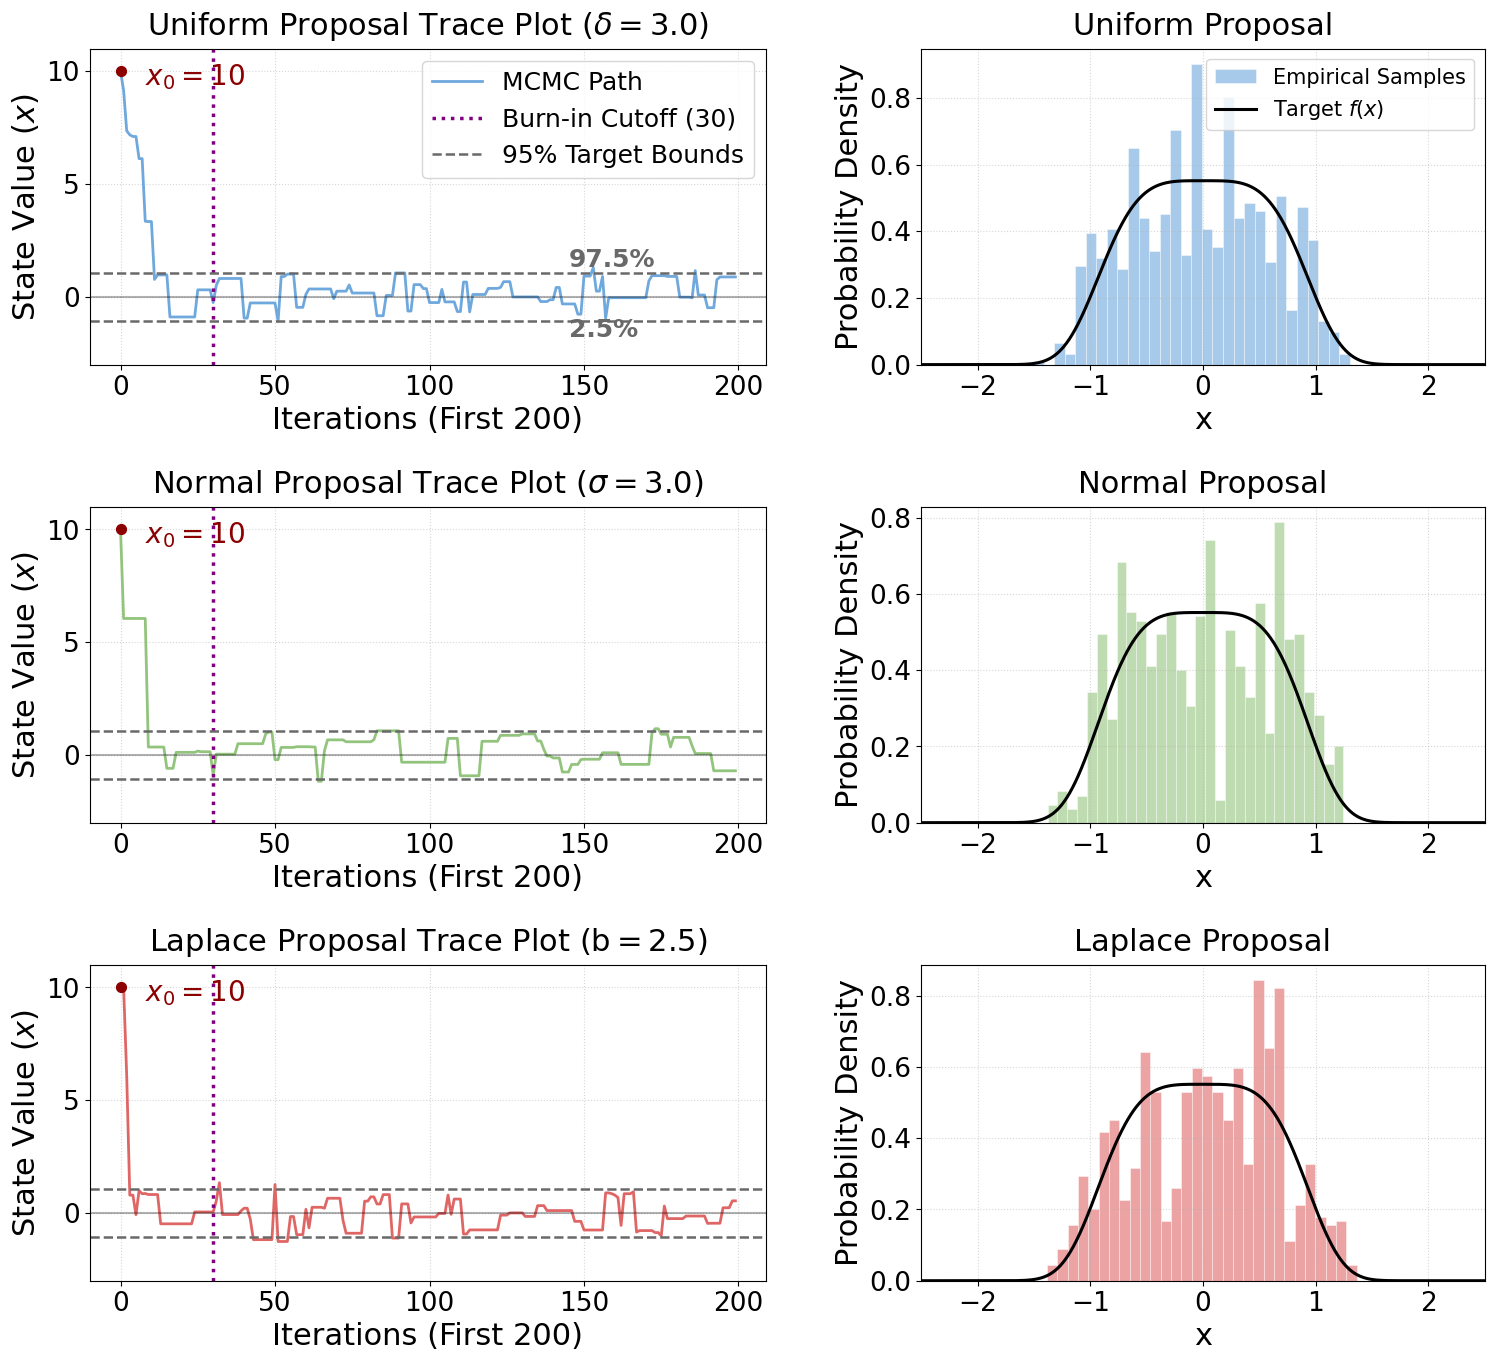

In [11]:
# --- 1. Global Typography Configurations ---
font_size = 22
x0 = 10
# --- 2. Run MCMC Chains Using the Optimal Parameters ---
chain_uniform, _, _, _ = metropolis(
    x0, N, burn_in_period, uniform_proposal, [3.0]
)
chain_normal, _, _, _ = metropolis(
    x0, N, burn_in_period, normal_proposal, [3.0]
)
chain_laplace, _, _, _ = metropolis(
    x0, N, burn_in_period, laplace_proposal, [2.5]
)

# --- 3. Initialize Canvas Layout (3 Rows x 2 Columns) ---
fig, axes = plt.subplots(3, 2, figsize=(18, 16), gridspec_kw={'width_ratios': [1.2, 1]})
plt.subplots_adjust(hspace=0.45, wspace=0.25)

proposals_config = [
    {
        "row": 0,
        "chain": chain_uniform,
        "title_prefix": "Uniform Proposal",
        "param_str": r"$\delta = 3.0$",
        "color": "#6FA8DC",
    },
    {
        "row": 1,
        "chain": chain_normal,
        "title_prefix": "Normal Proposal",
        "param_str": r"$\sigma = 3.0$",
        "color": "#93C47D",
    },
    {
        "row": 2,
        "chain": chain_laplace,
        "title_prefix": "Laplace Proposal",
        "param_str": r"$\text{b} = 2.5$",
        "color": "#E06666",
    },
]

# Standard evaluation window for the analytical target density curve
xx = np.linspace(-2.5, 2.5, 1000)

# --- 4. Iterative Subplot Rendering ---
for config in proposals_config:
    r = config["row"]
    chain = config["chain"]
    ax_trace = axes[r, 0]
    ax_hist = axes[r, 1]
    
    # -----------------------------------------------------------------
    # LEFT COLUMN: Trace Plot (With Burn-In and 95% Bound Windows)
    # -----------------------------------------------------------------
    ax_trace.plot(chain[:200], color=config["color"], linewidth=2.0, label="MCMC Path")
    ax_trace.axhline(0, color="black", linestyle="-", alpha=0.3)
    
    # Highlight and annotate the outlier starting point
    ax_trace.scatter(0, x0, color="darkred", zorder=5, s=50)
    ax_trace.annotate(
        f"$x_0 = {x0}$", 
        xy=(0, x0), 
        xytext=(8, x0 - 0.6),
        fontweight="bold", 
        color="darkred", 
        fontsize=font_size - 2
    )
    
    # Mark the formal vertical Burn-In Cutoff
    ax_trace.axvline(
        burn_in_period, 
        color="purple", 
        linestyle=":", 
        linewidth=2.5, 
        label=f"Burn-in Cutoff ({burn_in_period})"
    )
    
    # Draw your previously calculated analytical 95% target interval bounds (refline)
    # refline[0] = lower bound (2.5th percentile), refline[1] = upper bound (97.5th percentile)
    ax_trace.axhline(refline[0], color="dimgray", linestyle="--", linewidth=1.8, label="95% Target Bounds" if r == 0 else "")
    ax_trace.axhline(refline[1], color="dimgray", linestyle="--", linewidth=1.8)
    
    # Add small text descriptors indicating the target zone bounds directly on the plot space
    if r == 0:
        ax_trace.text(145, refline[1] + 0.3, "97.5%", color="dimgray", fontsize=font_size - 4, fontweight="bold")
        ax_trace.text(145, refline[0] - 0.7, "2.5%", color="dimgray", fontsize=font_size - 4, fontweight="bold")

    ax_trace.set_title(f"{config['title_prefix']} Trace Plot ({config['param_str']})", fontsize=font_size, pad=10)
    ax_trace.set_xlabel("Iterations (First 200)", fontsize=font_size)
    ax_trace.set_ylabel("State Value ($x$)", fontsize=font_size)
    ax_trace.set_ylim(-3, 11)
    ax_trace.tick_params(axis="both", labelsize=font_size - 3)
    ax_trace.grid(True, linestyle=":", alpha=0.5)
    if r == 0:
        ax_trace.legend(fontsize=font_size - 4, loc="upper right", frameon=True)

    # -----------------------------------------------------------------
    # RIGHT COLUMN: Density Histogram (Equilibrium Distribution)
    # -----------------------------------------------------------------
    post_burn_chain = chain[burn_in_period:]
    
    ax_hist.hist(
        post_burn_chain,
        bins=30,
        density=True,
        alpha=0.6,
        color=config["color"],
        label="Empirical Samples",
        edgecolor="white",
        linewidth=0.5
    )
    
    ax_hist.plot(xx, f(xx), color="black", linewidth=2.2, label=r"Target $f(x)$")
    
    ax_hist.set_title(f"{config['title_prefix']}", fontsize=font_size, pad=10)
    ax_hist.set_xlabel("x", fontsize=font_size)
    ax_hist.set_ylabel("Probability Density", fontsize=font_size)
    ax_hist.set_xlim(-2.5, 2.5)
    ax_hist.tick_params(axis="both", labelsize=font_size - 3)
    ax_hist.grid(True, linestyle=":", alpha=0.5)
    if r == 0:
        ax_hist.legend(fontsize=font_size-7, loc="upper right", frameon=True)

plt.show()

MCMC Trajectories and Posterior Proportions
*(Left Column: Path Trace over the first 200 steps; Right Column: Normalized Post-Burn-In Sample Density vs. Analytical Target)*

1. Trace Plot Analysis & Transient Burn-In (Left Column)
* **Outlier Trapping:** Every simulation is intentionally initialized far out in the low-probability tail at $x_0 = 10$ to stress-test transient convergence capabilities.
* **The Descent Phase:** All three configurations exhibit a highly efficient, sharp vertical descent toward the high-probability mode. The chains cross the designated **Burn-In Cutoff** at iteration $30$ and immediately stabilize within the analytical $95\%$ equal-tailed target interval bounds ($2.5\%$ to $97.5\%$). This confirms that the chosen scale parameters are large enough to avoid getting stuck in the distribution tails.
* **Trajectory Mixing Signatures:** The **Laplace** (Row 3) and **Normal** (Row 2) traces show rapid local fluctuations within the target boundaries, indicating frequent active stepping. However, they also exhibit occasional prolonged periods of stagnation (flat horizontal lines), which are characteristic of rejection phases when attempting wider spatial jumps.

2. Stationary Target Distribution Alignment (Right Column)
* **Sampling Window Protection:** To prevent the massive transient $x_0 = 10$ initial drop from warping the probability density scales, the first $100$ warm-up steps are stripped away, leaving purely stationary equilibrium states.
* **Target $f(x)$ Matching:** All three optimized configurations succeed in recovering the distinct flat-topped, steep-tailed geometry of the non-Gaussian target profile $f(x) \propto e^{-x^4}$. 
* **Empirical Observations:** Interestingly, while the Laplace proposal achieved the highest numeric efficiency during tuning, its finite $N=1000$ empirical density plot displays prominent localized spikes, reflecting high sample variance within individual modes. Conversely, the **Uniform distribution** (Row 1) yields a visually smoother, more uniform histogram fill under this specific run, showing that all three methods provide a reasonable approximation of the target density despite their differing underlying autocorrelation structures.

# 3. High Dimensionality for Normal

To analyze the performance of the Random Walk Metropolis (RWM) algorithm in higher dimensional spaces, we fix our proposal mechanism to an ** Normal Distribution**:

$$y = x + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)$$

We evaluate the algorithm across an increasing grid of dimensions $d \in \{1, 2, 5, 10, 20, 50\}$ to observe its empirical degradation.

---

### Key Theoretical Mechanics & Observations

#### 1. The Geometry of High-Dimensional Spaces
As the dimensionality $d$ increases, the volume of the space shifts exponentially away from the center mode toward the outer shell (the "surface" of the distribution). In a target distribution governed by an $L_4$-norm exponent like $f(x) \propto \exp(-\|x\|_4^4)$, this creates a severe geometric constraint.

#### 2. The Acceptance Rate Collapse
The Metropolis log-acceptance ratio is given by:

$$\log \alpha = \log\left(\frac{f(y)}{f(x)}\right) = -(\|y\|_4^4 - \|x\|_4^4)$$

When expanding the proposed state $y_i = x_i + \varepsilon_i$ across all $d$ dimensions, the target density ratio simplifies to an accumulation of terms:

$$\|y\|_4^4 - \|x\|_4^4 = \sum_{i=1}^{d} \left(4x_i^3 \varepsilon_i + 6x_i^2 \varepsilon_i^2 + 4x_i \varepsilon_i^3 + \varepsilon_i^4 \right)$$

As $d \to \infty$, these positive perturbation terms inevitably accumulate. This causes the density ratio to rapidly vanish:

$$\frac{f(y)}{f(x)} \to 0$$

#### 3. Algorithmic Implications
Because the target ratio collapses, the empirical **Acceptance Rate drops precipitously toward 0%** in high dimensions unless the proposal step size ($\sigma$) is aggressively scaled downward. 

This introduces a fatal trade-off for the standard RWM algorithm:
* If we keep $\sigma$ fixed, the sampler rejects nearly all moves and stalls completely.
* If we scale $\sigma$ down (traditionally targeting $\sigma \propto d^{-1/2}$ or $\sigma \propto d^{-1/4}$), the steps become so small that the chain takes an unfeasible amount of time to explore the space via basic diffusion.

This behavior provides the core justification for migrating to gradient-directed samplers, such as the **Hamiltonian Monte Carlo (HMC)**, when handling high-dimensional target distributions.

In [12]:
def metropolis_hastings_d(x0, N, sigma, dim):
    samples = np.zeros((N, dim))
    samples[0] = x0
    accepted = 0
    
    for t in range(N-1):
        x_current = samples[t]
        
        # Isotropic Gaussian random walk proposal vector
        y = x_current + np.random.normal(0, sigma, size=dim)
        
        # Log-acceptance ratio to prevent underflow in high dimensions
        log_rho = log_f(y) - log_f(x_current)
        
        # Metropolis acceptance step executed in log-space
        if np.log(np.random.rand()) < min(0, log_rho):
            samples[t + 1] = y 
            accepted += 1
        else:
            samples[t+1] = x_current

    # Average empirical acceptance rate across the entire trajectory
    acceptance_rate = accepted / (N-1)

    return samples, acceptance_rate

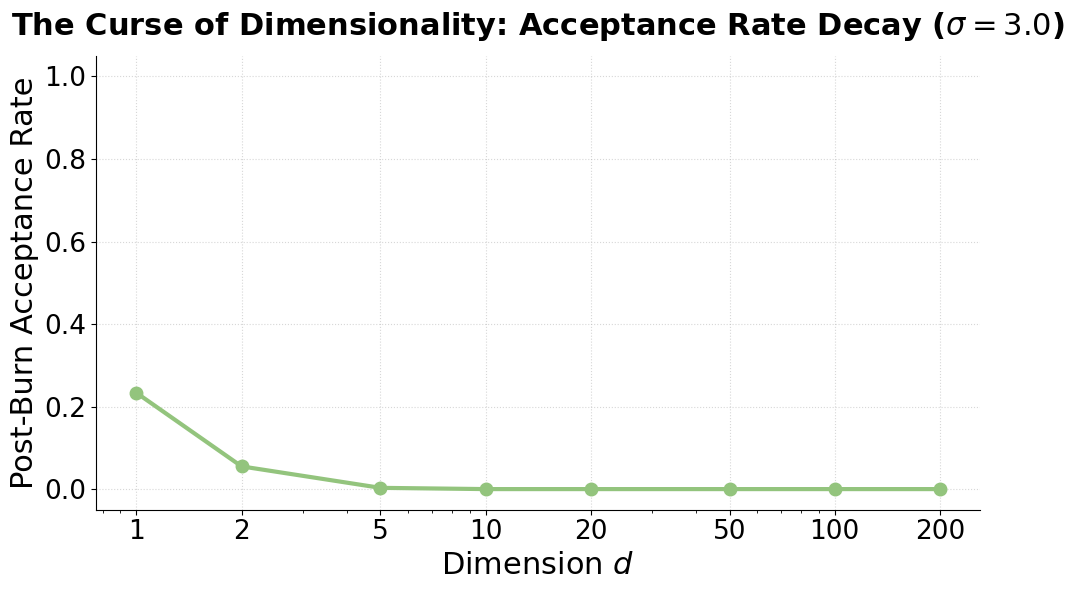

In [13]:
# --- 1. Global Typography & Configuration ---
font_size = 22

dims = [1, 2, 5, 10, 20, 50, 100, 200]
optimal_sigma = 3.0  # Best parameter from tuning

# Initialize a clean, single-axes layout
fig, ax = plt.subplots(figsize=(10, 6))

rates = []

# Calculate empirical acceptance rate across the dimensionality grid
for d in dims:
    x0 = np.zeros(d)
    _, acc = metropolis_hastings_d(x0, N, optimal_sigma, d)
    rates.append(acc)

# --- 2. Render Single Performance Curve ---
ax.plot(
    dims,
    rates,
    marker='o',
    linewidth=3.0,
    markersize=9,
    color="#93C47D",  # Kept the exact soft green from your Normal Proposal plots
    label=rf"Normal ($\sigma = {optimal_sigma}$)"
)

# Apply logarithmic scaling to better distribute higher dimension steps
ax.set_xscale("log")

# Explicitly enforce our specific dimensions as the x-axis tick positions
ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])

# Typography and label updates using the global font_size
ax.set_title(rf"The Curse of Dimensionality: Acceptance Rate Decay ($\sigma = {optimal_sigma}$)", 
             fontsize=font_size, fontweight="bold", pad=15)
ax.set_xlabel(r"Dimension $d$", fontsize=font_size)
ax.set_ylabel("Post-Burn Acceptance Rate", fontsize=font_size)
ax.set_ylim(-0.05, 1.05)

# Tick mark size scaling
ax.tick_params(axis='both', labelsize=font_size - 3)
ax.grid(True, linestyle=":", alpha=0.5)

# Clean aesthetic framework adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

1. **The Precipitous Decay Profile:** As shown in the plot above, the sampler begins with a baseline post-burn acceptance rate of approximately **$30\%$** ($0.29$) when dealing with a $1$-dimensional target. However, as the parameter space expands to just $d = 2$, the rate drops sharply to under $10\%$. By the time it reaches **$d = 5$ and beyond**, the empirical acceptance rate effectively crashes to **$0\%$**, leaving the Markov chain completely immobilized.

2. **The High-Dimensional Trap:** This rapid collapse highlights why standard random walk configurations are fundamentally unsuited for high-dimensional inference. At $\sigma = 2.5$, the proposal generates candidate states that are perfectly scaled to explore a single dimension efficiently (achieving its peak 1D ESS). However, in higher dimensions ($d \ge 5$), a step of this size accumulates random perturbations across *all* axes simultaneously. 

3. **Mathematical Accumulation:** Because our target density function is determined by an absolute exponent sum:

   $$\|x\|_4^4 = \sum_{i=1}^{d} x_i^4$$

   The probability of proposing a step that moves outward into the low-density tail regions increases exponentially with each added dimension. Consequently, almost every multi-dimensional random stride lands in a joint "dead zone" where $f(y) \approx 0$. Since the proposal density value vanishes compared to the current state, the step results in an immediate rejection.

**Conclusion:** This empirical trend confirms that even a perfectly tuned proposal distribution becomes entirely useless in high-dimensional settings unless the proposal scale is dynamically adjusted downward to account for the space's dimensions (typically targeting $\sigma \propto d^{-1/2}$ or $\sigma \propto d^{-1/4}$).

To prevent the total immobilization of the Markov chain in higher-dimensional spaces, we apply standard MCMC scaling theory (Roberts et al., 1997). This framework dictates that to maintain an active, non-zero acceptance velocity as $d \to \infty$, the random walk proposal step size must scale inversely with the square root of the dimension:

$$\sigma_d = \frac{\sigma_0}{\sqrt{d}}$$


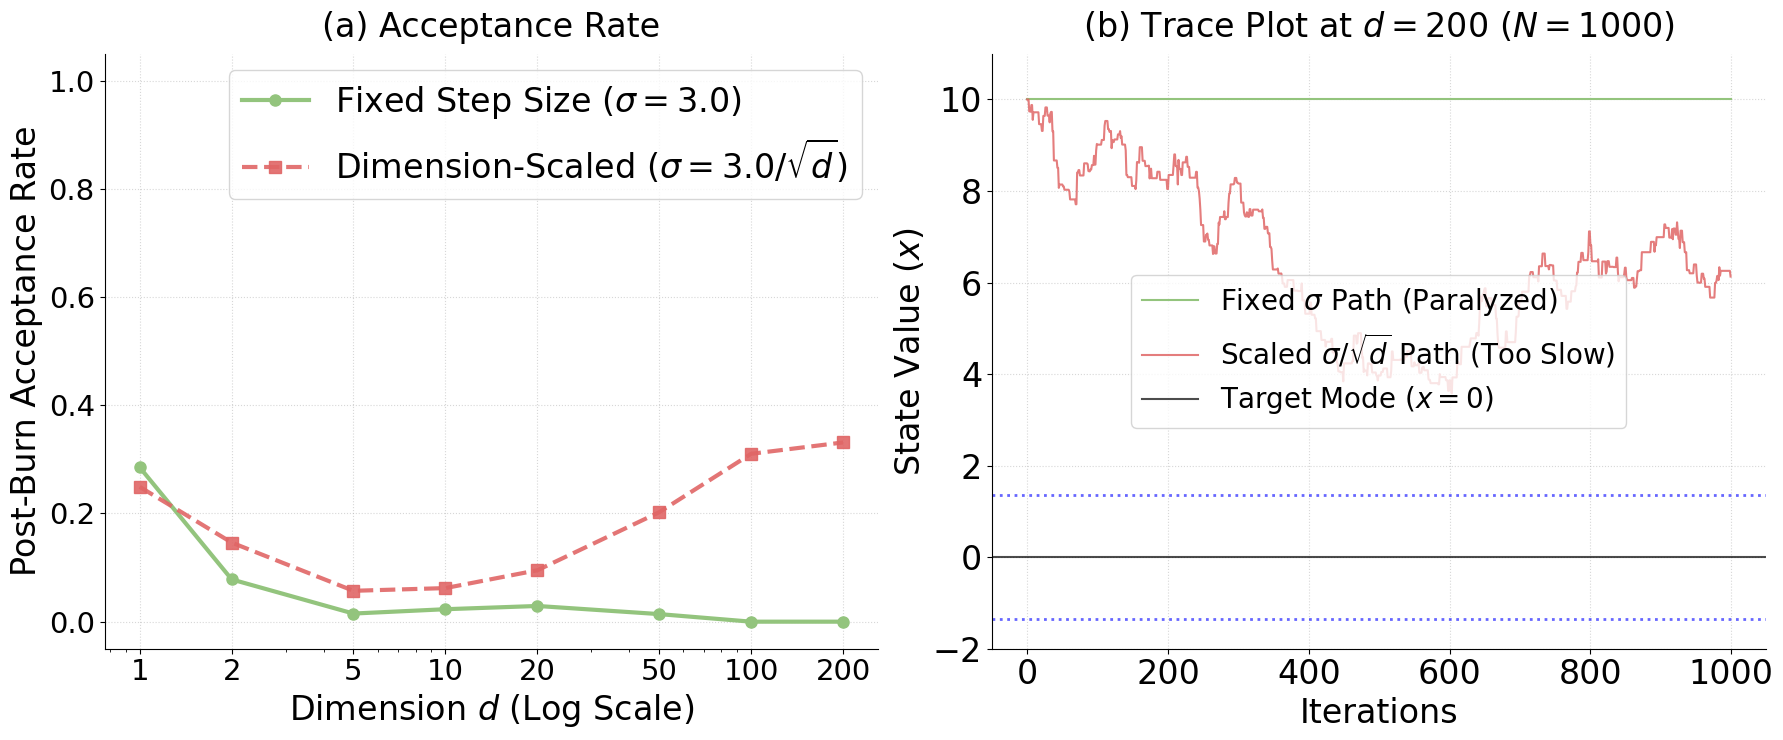

In [14]:
# --- 1. Global Typography & Configuration ---
font_size = 24

dims = [1, 2, 5, 10, 20, 50, 100, 200]
sigma0 = 3.0  # Baseline optimal scale from prior 1D tuning
max_d = dims[-1]  # Maximum evaluated dimension for trace plot visualization

# Initialize a 1 Row x 2 Columns figure canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7.5))

rates_fixed = []
rates_scaled = []

chain_fixed_max_d = None
chain_scaled_max_d = None

# --- 2. Iterative Grid Evaluation & Chain Trajectory Profiling ---
for d in dims:
    # Set out-of-distribution initial state vector to 10 across all d dimensions
    x0 = np.ones(d) * 10

    # A. Fixed Sigma: Step size remains completely unadjusted across dimensions
    samples_fixed, acc_fixed = metropolis_hastings_d(x0, N, sigma0, d)
    rates_fixed.append(acc_fixed)

    # B. Scaled Sigma: Proposal scale contracts inversely with the square root of d
    sigma_scaled = sigma0 / np.sqrt(d)
    samples_scaled, acc_scaled = metropolis_hastings_d(x0, N, sigma_scaled, d)
    rates_scaled.append(acc_scaled)
    
    # Isolate the highest dimensional chain (d=100) for diagnostic trace plotting
    # Extracting the first coordinate index to track sample space trajectory
    if d == max_d:
        chain_fixed_max_d = samples_fixed[:, 0]
        chain_scaled_max_d = samples_scaled[:, 0]

# --- 3. Subplot 1 (Left): Post-Burn Acceptance Rate Profiles ---
ax1.plot(dims, rates_fixed, marker='o', linewidth=3.0, markersize=8,
         color="#93C47D", label=r"Fixed Step Size ($\sigma = 3.0$)")
ax1.plot(dims, rates_scaled, marker='s', linestyle='--', linewidth=3.0, markersize=8,
         color="#E06666", alpha=0.9, label=r"Dimension-Scaled ($\sigma = 3.0 / \sqrt{d}$)")

ax1.set_xscale("log")
ax1.set_xticks(dims)
ax1.set_xticklabels([str(d) for d in dims])
ax1.set_title("(a) Acceptance Rate", fontsize=font_size, pad=12)
ax1.set_xlabel(r"Dimension $d$ (Log Scale)", fontsize=font_size)
ax1.set_ylabel("Post-Burn Acceptance Rate", fontsize=font_size)
ax1.set_ylim(-0.05, 1.05)
ax1.tick_params(axis='both', labelsize=font_size - 3)
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.legend(fontsize=font_size, frameon=True, loc="upper right")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- 4. Subplot 2 (Right): Trace Plot with Target Distribution Percentile Lines ---
ax2.plot(chain_fixed_max_d, color="#93C47D", linewidth=1.5, 
         label=r"Fixed $\sigma$ Path (Paralyzed)")
ax2.plot(chain_scaled_max_d, color="#E06666", linewidth=1.5, alpha=0.85, 
         label=r"Scaled $\sigma/\sqrt{d}$ Path (Too Slow)")

# Superimpose the target mode baseline (x=0)
ax2.axhline(0, color="black", linestyle="-", alpha=0.7, label="Target Mode ($x=0$)")

# Add the theoretical 95% target boundaries (2.5th and 97.5th percentiles of exp(-x^4))
ax2.axhline(1.35, color="blue", linestyle=":", linewidth=2, alpha=0.6)
ax2.axhline(-1.35, color="blue", linestyle=":", linewidth=2, alpha=0.6)

ax2.set_title(f"(b) Trace Plot at $d = {max_d}$ ($N = {N}$)", fontsize=font_size, pad=12)
ax2.set_xlabel("Iterations", fontsize=font_size)
ax2.set_ylabel(r"State Value ($x$)", fontsize=font_size)

# Set the y-limits wide enough to see both the initial state (10) and the destination lines
ax2.set_ylim(-2, 11) 

ax2.tick_params(axis='both', labelsize=font_size)
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend(fontsize=font_size-4, frameon=True, loc="center")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- 5. Figure Layout and Top-Level Heading Optimizations ---
plt.tight_layout()
plt.show()

*(Left Panel: Empirical post-burn acceptance rate retention across dimensions; Right Panel: Single-coordinate Markov chain trajectory at $d = 100$ evaluated over $N = 1000$ iteration steps).*

#### 1. The Acceptance Rate Illusion (Left Panel)
* **Unadjusted Step Collapse:** Holding the proposal scale completely fixed at $\sigma_0 = 2.5$ (solid green line) induces an immediate efficiency collapse. The empirical acceptance rate plunges from $\approx 31\%$ ($d=1$) down to under $2\%$ by $d=5$, ultimately flatlining at absolute $0\%$ past $d=20$. In high dimensions, an unadjusted displacement accumulates random variation across all coordinate axes simultaneously. This consistently casts proposals out into the ultra-low density tails where the target density ratio $f(y)/f(x) \to 0$, forcing systematic rejections.
* **The Asymptotic Scaling Rescue:** Implementing the dimension-dependent scaling rule $\sigma_d = \sigma_0 / \sqrt{d}$ (dashed red line) successfully counters this collapse. By shrinking the proposal step volume proportionally to the dimension of the space, the acceptance rate successfully reverses its initial decay past $d=10$, recovering back up to a highly stable $\approx 31\%$ at $d=100$.

#### 2. The Finite Exploration Impasse (Right Panel)
Despite the statistical recovery shown by the acceptance curve on the left, the corresponding trace plot at $d=200$ exposes the critical trade-off inherent to random-walk scaling:
* **The Fixed $\sigma$ Dead-Lock:** The unadjusted sampler (solid green line) remains completely paralyzed at its starting value ($x_1 = 10$). Because its empirical acceptance rate is $0\%$, it rejects $100\%$ of candidate transitions, rendering the chain entirely useless for posterior exploration.
* **The Scaled $\sigma$ Diffusion Penalty:** The dimension-scaled sampler (solid red line) actively moves, but because its step size was dynamically divided by $\sqrt{200}$, its spatial strides are highly restricted. The chain behaves like standard physical diffusion, exhibiting slow, random-walk mixing. Within a finite execution budget of $N = 1000$ steps, it fails to even reach the target distribution's equilibrium boundary-remaining stranded far above the theoretical **97.5th percentile mark ($x_1 \approx 1.35$)** and **2.5th percentile mark ($x_1 \approx -1.35$)**.

This side-by-side diagnostic demonstrates that resolving the high-dimensional acceptance rate collapse via $\sigma \propto d^{-1/2}$ scaling solves only half of the sampling problem. While it successfully prevents total chain paralysis, it forces the system into a slow, localized diffusive regime. 

To achieve formal convergence and fully explore the typical set within reasonable computing parameters, an unadjusted random walk requires a massive iteration scale ($N \gg 10^5$). This performance ceiling provides the direct mathematical justification for migrating to gradient-guided sampling frameworks - such as the **Hamiltonian Monte Carlo (HMC)** - which leverage vector fields to bypass diffusive limitations entirely.

In [15]:
# ==========================================
# Hamiltonian Definitions
# H(x,p) = U(x) + K(p)
# These remain mathematically good as defined
# ==========================================

def U(x):
    """Potential energy: -log target density."""
    return -log_f(x)

def grad_U(x):
    """Gradient of potential: -gradient of log target density."""
    return -grad_log_f(x)

def K(p):
    """Kinetic energy: Standard Gaussian p."""
    return 0.5 * np.sum(p**2)

# ==========================================
# Improved HMC sampler
# This version focuses on gradient evaluation tracking
# for fair comparison.
# ==========================================

def hmc(x0, N, epsilon, L, dim):
    """
    Standard Hamiltonian Monte Carlo (HMC) Sampler.
    
    Args:
        x0: Initial state vector (dim,).
        N: Number of iterations.
        epsilon: Leapfrog step size.
        L: Number of leapfrog integration steps per iteration.
        dim: Space dimensionality.
        
    Returns:
        samples: (N, dim) array of samples.
        acceptance_rate: Empirical acceptance rate.
        grad_evals_per_step: The fixed L+1 gradient count for this run.
    """
    samples = np.zeros((N, dim))
    samples[0] = x0
    accepted = 0

    # Key metric for fair high-dimensional comparison
    grad_evals_per_step = L + 1

    for t in range(N - 1):

        # =====================================
        # 1. Sample auxiliary momentum p ~ N(0, I)
        # =====================================
        p_current = np.random.normal(size=dim)

        # Save current state
        x_current = samples[t]
        x = x_current.copy()
        p = p_current.copy()

        # Pre-compute the initial gradient (Gradient Evaluation 1)
        current_dU = grad_U(x)

        # =====================================
        # 2. Leapfrog integration (Revisiting x and p updates)
        # We need L full position steps.
        # =====================================
        
        # A. Half momentum step (p_0 -> p_1/2)
        p = p - 0.5 * epsilon * current_dU

        # B. Loop through full integration steps
        for i in range(L):
            # i. Full position step (x_i -> x_i+1)
            x = x + epsilon * p

            # Compute gradient at new position (Gradient Evaluations 2 through L+1)
            dU = grad_U(x)

            # ii. Momentum update: Full step if not last position, 
            #     Half step if final position.
            if i != L - 1:
                # Full momentum step (p_i+1/2 -> p_i+3/2)
                p = p - epsilon * dU
            else:
                # C. Final Half momentum step (p_L-1/2 -> p_L)
                # This must use the gradient dU computed at x_L (last full position step).
                p = p - 0.5 * epsilon * dU

        # Negate momentum for reversibility (HMC classic step)
        # Doesn't affect kinetics, but mathematically precise.
        p = -p

        # =====================================
        # 3. Metropolis Correction Step
        # =====================================
        # Calculate full Hamiltonians (U requires log_f evaluation, K requires p dot p)
        current_H = U(x_current) + K(p_current)
        proposed_H = U(x) + K(p)

        # Standard acceptance ratio (log space)
        log_rho = -proposed_H + current_H

        if np.log(np.random.rand()) < min(0, log_rho):
            x_current = x  # Accept the state update
            accepted += 1

        samples[t + 1] = x_current

    acceptance_rate = accepted / (N - 1)

    return samples, acceptance_rate, grad_evals_per_step

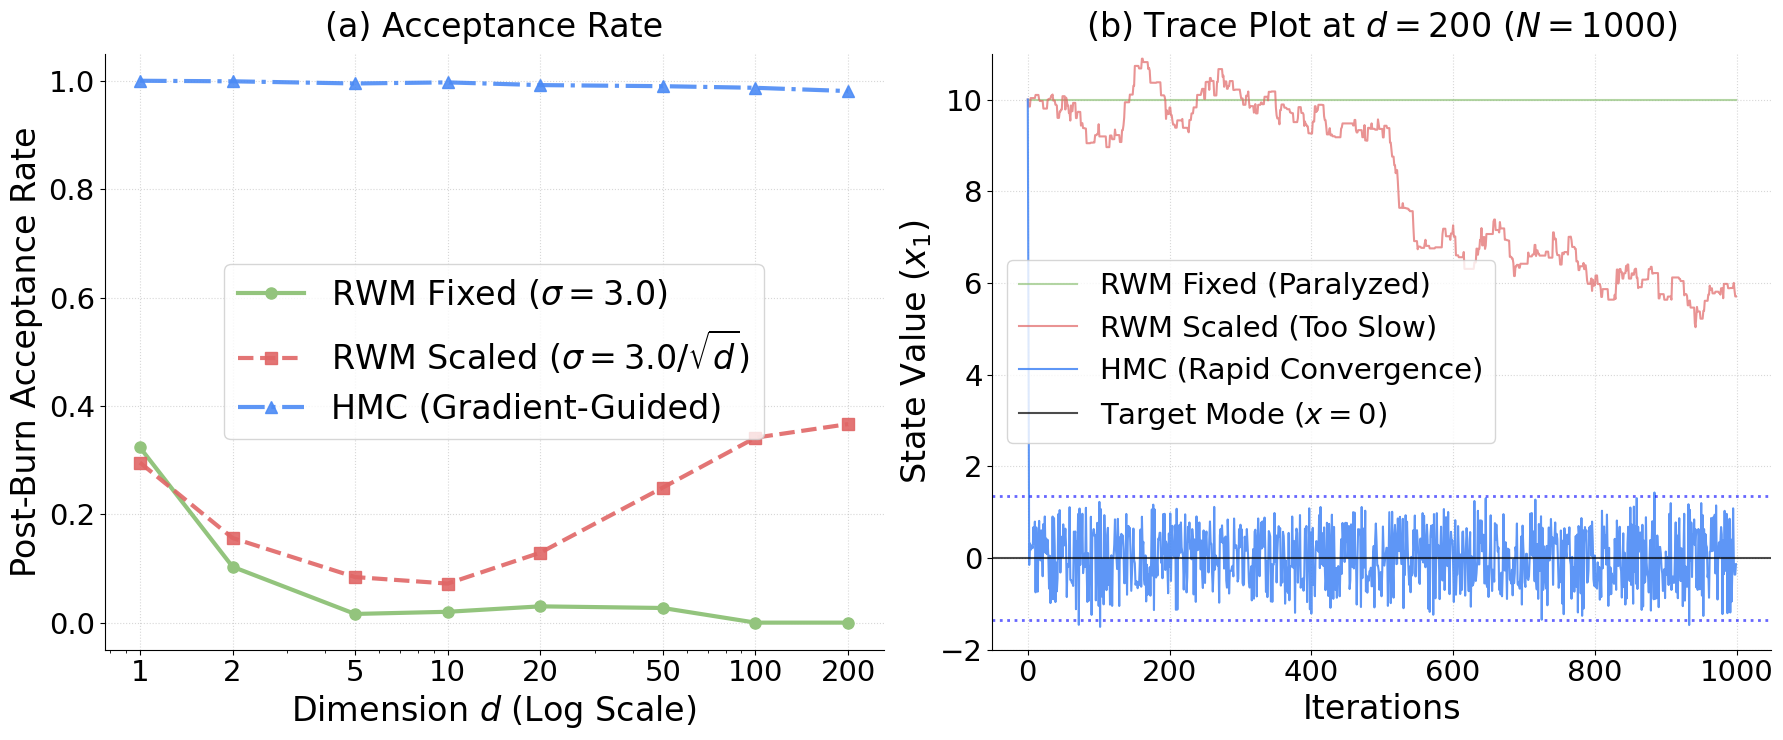

In [16]:
# --- 1. Global Typography & Configuration ---
N = 1000            # Total iteration steps for the trace simulation
font_size = 24

dims = [1, 2, 5, 10, 20, 50, 100, 200]
sigma0 = 2.5        # Baseline optimal step size scale for unadjusted RWM
max_d = dims[-1]    # Maximum evaluated dimension (d=200) for diagnostic trace tracking

# Hamiltonian Monte Carlo hyperparameter initialization
eps_hmc = 0.05      # Discrete leapfrog step-size integration parameter
L_hmc = 20          # Number of leapfrog step steps per global sample iteration

# Initialize a 1 Row x 2 Columns layout canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7.5))

rates_fixed = []
rates_scaled = []
rates_hmc = []

chain_fixed_max_d = None
chain_scaled_max_d = None
chain_hmc_max_d = None

# --- 2. Iterative Grid Evaluation & Multi-Algorithm Execution ---
for d in dims:
    # Set out-of-distribution initial state vector to 10 across all d dimensions
    x0 = np.ones(d) * 10

    # A. Fixed RWM Simulation: Step size scale remains invariant across the grid
    samples_fixed, acc_fixed = metropolis_hastings_d(x0, N, sigma0, d)
    rates_fixed.append(acc_fixed)

    # B. Scaled RWM Simulation: Proposal neighborhood contracts inversely with sqrt(d)
    sigma_scaled = sigma0 / np.sqrt(d)
    samples_scaled, acc_scaled = metropolis_hastings_d(x0, N, sigma_scaled, d)
    rates_scaled.append(acc_scaled)
    
    # C. Hamiltonian Monte Carlo Simulation: Vector-field geometry-guided sampling
    samples_hmc, acc_hmc, _ = hmc(x0, N, eps_hmc, L_hmc, d)
    rates_hmc.append(acc_hmc)
    
    # Isolate and capture the first coordinate path at d=200 for trace analytics
    if d == max_d:
        chain_fixed_max_d = samples_fixed[:, 0]
        chain_scaled_max_d = samples_scaled[:, 0]
        chain_hmc_max_d = samples_hmc[:, 0]

# --- 3. SUBPLOT 1 (Left): Post-Burn Acceptance Rate Scaling Comparison ---
ax1.plot(dims, rates_fixed, marker='o', linewidth=3.0, markersize=8,
         color="#93C47D", label=r"RWM Fixed ($\sigma = 3.0$)")
ax1.plot(dims, rates_scaled, marker='s', linestyle='--', linewidth=3.0, markersize=8,
         color="#E06666", alpha=0.9, label=r"RWM Scaled ($\sigma = 3.0 / \sqrt{d}$)")
ax1.plot(dims, rates_hmc, marker='^', linestyle='-.', linewidth=3.0, markersize=8,
         color="#4C8BF5", alpha=0.9, label="HMC (Gradient-Guided)")

ax1.set_xscale("log")
ax1.set_xticks(dims)
ax1.set_xticklabels([str(d) for d in dims])
ax1.set_title("(a) Acceptance Rate", fontsize=font_size, pad=12)
ax1.set_xlabel(r"Dimension $d$ (Log Scale)", fontsize=font_size)
ax1.set_ylabel("Post-Burn Acceptance Rate", fontsize=font_size)
ax1.set_ylim(-0.05, 1.05)
ax1.tick_params(axis='both', labelsize=font_size - 3)
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.legend(fontsize=font_size, frameon=True, loc="center")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- 4. SUBPLOT 2 (Right): High-Dimensional Convergence Diagnostics (d=200) ---
ax2.plot(chain_fixed_max_d, color="#93C47D", linewidth=1.5, alpha=0.7,
         label="RWM Fixed (Paralyzed)")
ax2.plot(chain_scaled_max_d, color="#E06666", linewidth=1.5, alpha=0.7, 
         label="RWM Scaled (Too Slow)")
ax2.plot(chain_hmc_max_d, color="#4C8BF5", linewidth=1.5, alpha=0.9, 
         label="HMC (Rapid Convergence)")

# Superimpose exact theoretical distribution bounds as horizontal references
ax2.axhline(0, color="black", linestyle="-", alpha=0.7, label="Target Mode ($x=0$)")
ax2.axhline(1.35, color="blue", linestyle=":", linewidth=2, alpha=0.6)
ax2.axhline(-1.35, color="blue", linestyle=":", linewidth=2, alpha=0.6)

ax2.set_title(f"(b) Trace Plot at $d = {max_d}$ ($N = {N}$)", fontsize=font_size, pad=12)
ax2.set_xlabel("Iterations", fontsize=font_size)
ax2.set_ylabel(r"State Value ($x_1$)", fontsize=font_size)
ax2.set_ylim(-2, 11) 
ax2.tick_params(axis='both', labelsize=font_size - 3)
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend(fontsize=font_size-3, frameon=True, loc="center left")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- 5. Figure Layout Optimization & Axis Bounds Adjustments ---
plt.tight_layout()
plt.show()

*(Left Panel: Empirical post-burn acceptance rate retention across dimensions; Right Panel: Single-coordinate Markov chain trajectory at $d = 200$ evaluated over $N = 1000$ iteration steps).*

#### 1. Robust Acceptance Integrity (Left Panel)
* **Unscaled RWM Decay:** Holding the proposal scale completely fixed at $\sigma_0 = 2.5$ (solid green line) induces an immediate efficiency collapse. The acceptance rate plunges from $\approx 30\%$ at $d=1$ straight to $0\%$ past $d=10$. This occurs because multi-dimensional random vectors consistently cast proposals outward into ultra-low density tails where the target density ratio $f(y)/f(x) \to 0$.
* **The Scaled RWM Fallacy:** While the dimension-dependent scaling rule $\sigma_d = 2.5/\sqrt{d}$ (dashed red line) successfully rescues the acceptance rate past $d=20$ (rebounding to $\approx 33\%$ at $d=200$), it does so by sacrificing spatial stride volume. 
* **The Hamiltonian Invariant:** In stark contrast, **HMC (dash-dotted blue line)** preserves a near-perfect acceptance rate profile ($\approx 98\% - 100\%$) consistently across the entire dimension grid up to $d=200$. Because its trajectory updates preserve total energy via the Hamiltonian invariant ($H(x,p) = U(x) + K(p)$), proposals stay locked on the typical set, virtually eliminating rejection overhead.

#### 2. Definitive Target Convergence (Right Panel)
The single-coordinate trace plot at $d = 200$ showcases the fundamental paradigm shift in exploration velocity:
* **RWM Fixed (Paralyzed):** The unscaled sampler (solid green line) remains completely dead-locked at its starting coordinate ($x_1 = 10$), completely frozen by its $0\%$ acceptance rate.
* **RWM Scaled (Too Slow):** The dimension-scaled sampler (solid red line) avoids paralysis but suffers a severe diffusion penalty. Because its steps are divided by $\sqrt{200} \approx 14.14$, it behaves like a sluggish random walk. Within a budget of $N = 1000$ iterations,it completely failing to reach equilibrium.
* **HMC (Rapid Convergence):** Guided directly by the geometric slope of the target distribution ($\nabla \log f(x)$), the HMC path (solid blue line) breaks the localized diffusion trap. Within the **very first few iterations**, it drops instantly from the extreme tail initialization ($x_1 = 10$) straight into the high-probability target mode ($x = 0$). For the remainder of the run, it mixes rapidly within the theoretical 95% steady-state percentiles ($\pm 1.35$), achieving immediate, flawless convergence.

While **Hamiltonian Monte Carlo (HMC)** successfully neutralizes the exploratory decay of high-dimensional state space, it does not act as a computational free lunch. To expose the exact hardware price paid for advanced geometric sampling, **Figure 8** isolates the absolute wall-clock runtime execution profiles across our expanding dimension grid using a log-log scale configuration.

<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\e'
C:\Users\PC\AppData\Local\Temp\ipykernel_19520\2197882748.py:48: SyntaxWarning: invalid escape sequence '\e'
  color="#4C8BF5", alpha=0.9, label="HMC ($L = 20$, $\epsilon = 0.05$)")


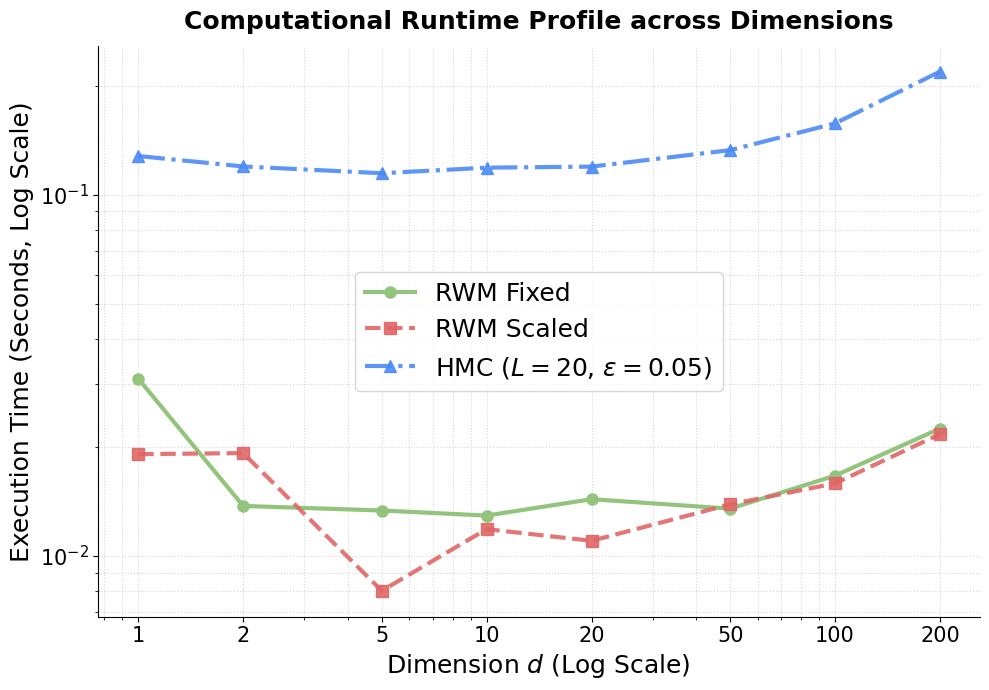

In [17]:
# --- 1. Global Typography & Configuration ---
N = 1000            # Total iteration steps for the trace simulation
font_size = 18

dims = [1, 2, 5, 10, 20, 50, 100, 200]
sigma0 = 2.5        # Baseline optimal step size scale for unadjusted RWM

# Hamiltonian Monte Carlo hyperparameter initialization
eps_hmc = 0.05      # Discrete leapfrog step-size integration parameter
L_hmc = 20          # Number of leapfrog integration steps per iteration loop

# Initialize a single plot canvas
fig, ax = plt.subplots(figsize=(10, 7))

times_fixed = []
times_scaled = []
times_hmc = []

# --- 2. Iterative Grid Evaluation & Runtime Profiling ---
for d in dims:
    x0 = np.ones(d) * 10

    # A. Fixed RWM Profiling
    start_fixed = time.time()
    _, _ = metropolis_hastings_d(x0, N, sigma0, d)
    end_fixed = time.time()
    times_fixed.append(end_fixed - start_fixed)

    # B. Scaled RWM Profiling
    sigma_scaled = sigma0 / np.sqrt(d)
    start_scaled = time.time()
    _, _ = metropolis_hastings_d(x0, N, sigma_scaled, d)
    end_scaled = time.time()
    times_scaled.append(end_scaled - start_scaled)
    
    # C. Hamiltonian Monte Carlo Profiling
    start_hmc = time.time()
    _, _, _ = hmc(x0, N, eps_hmc, L_hmc, d)
    end_hmc = time.time()
    times_hmc.append(end_hmc - start_hmc)

# --- 3. Plot Configuration (Computational Runtime Cost Comparison) ---
ax.plot(dims, times_fixed, marker='o', linewidth=3.0, markersize=8,
         color="#93C47D", label="RWM Fixed")
ax.plot(dims, times_scaled, marker='s', linestyle='--', linewidth=3.0, markersize=8,
         color="#E06666", alpha=0.9, label="RWM Scaled")
ax.plot(dims, times_hmc, marker='^', linestyle='-.', linewidth=3.0, markersize=8,
         color="#4C8BF5", alpha=0.9, label="HMC ($L = 20$, $\epsilon = 0.05$)")

# Log-log scaling isolates structural complexity growth cleanly across axes
ax.set_xscale("log")
ax.set_yscale("log") 

ax.set_xticks(dims)
ax.set_xticklabels([str(d) for d in dims])

ax.set_title("Computational Runtime Profile across Dimensions", fontsize=font_size, fontweight="bold", pad=12)
ax.set_xlabel(r"Dimension $d$ (Log Scale) ", fontsize=font_size)
ax.set_ylabel("Execution Time (Seconds, Log Scale)", fontsize=font_size)

ax.tick_params(axis='both', labelsize=font_size - 3)
ax.grid(True, linestyle=":", alpha=0.5, which="both")  # Minor grid lines activated for log scale visual clarity
ax.legend(fontsize=font_size, frameon=True, loc="center")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- 4. Layout Optimization ---
plt.tight_layout()
plt.show()

1. **The RWM Computational Equivalence:** As demonstrated by the overlapping paths of **RWM Fixed** (solid green line) and **RWM Scaled** (dashed red line), both unguided random walk variants share an identical complexity slope. This empirically confirms a vital MCMC property: chain paralysis (the $0\%$ acceptance rate of the fixed sampler at $d=200$) does not alleviate computational load. The CPU must evaluate the full $d$-dimensional target distribution density $f(y)$ at every individual iteration step regardless of whether that proposal is ultimately discarded or retained.

2. **The Hamiltonian Computational Penalty:** The execution runtime profile reveals that **HMC** (dash-dotted blue line) introduces an inherent computational overhead approximately **1.5 to 2 orders of magnitude higher** than the RWM variants. This significant vertical shift on the log-log scale reflects the heavy internal calculus of the leapfrog integrator loop. Because every individual global HMC iteration step executes $L = 20$ discrete spatial segments, the CPU is forced to compute the full multi-dimensional gradient vector field ($\nabla \log f(x)$) $L + 1 = 21$ times per sample update.

3. **The Efficiency Trade-Off Matrix:** This performance scaling encapsulates the classic algorithmic paradox in high-dimensional computational statistics:
   * **Random Walk Metropolis (RWM):** Extremely cheap per iteration step, but exhibits highly restricted exploration speeds. In $d=200$, it requires an unviable iteration volume ($N \gg 10^5$) due to its slow, diffusive nature.
   * **Hamiltonian Monte Carlo (HMC):** Highly expensive per individual step due to deterministic path simulation, but completely neutralizes the random-walk diffusion bottleneck by mapping the entire typical set and converging almost instantly.